# Bulk time-course analysis

A **time-course** (longitudinal) experiment samples the same biological system at a series of time points. Unlike a two-group comparison, the interesting question is not *"which genes differ between A and B"* but *"how does expression evolve over time"*. Three questions follow naturally:

1. **Which genes are temporally regulated?** Genes whose expression changes over the time course at all — regardless of trajectory shape.
2. **What shape does the change take?** Among the regulated genes, which rise, which fall, which peak transiently — the *expression waves*.
3. **Do trajectories differ between groups?** When there are several conditions (treated vs control), which genes have a *group-specific* time profile.

This tutorial walks through all three on the classic **yeast cell-cycle dataset** of Cho *et al.* (1998) — ~3000 genes profiled by microarray at 17 points across the cell cycle (the `cdc28` synchronisation series). It is the original demonstration dataset of Bioconductor's *Mfuzz*, and a perfect illustration: many genes oscillate with the cell cycle, each peaking at its own phase.

In [1]:
import omicverse as ov
import pymfuzz
import matplotlib.pyplot as plt

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...


🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the yeast cell-cycle data

`pymfuzz` ships the Cho *et al.* yeast dataset — `load_yeast()` returns an `ExpressionMatrix` of **3000 genes x 17 time points**. The 17 columns are the `cdc28` synchronised samples taken every 10 minutes (0 - 160 min), spanning roughly two cell cycles.

The values are **microarray log-expression** — log-ratios that can be negative, not RNA-seq counts. That matters for the statistical model below: this is *continuous*, already-normalised data.

In [2]:
yeast = pymfuzz.load_yeast()
print(yeast.shape, yeast.n_genes, 'genes x', yeast.n_time, 'time points')
list(yeast.time_names)

(3000, 17) 3000 genes x 17 time points


['cdc28_0',
 'cdc28_10',
 'cdc28_20',
 'cdc28_30',
 'cdc28_40',
 'cdc28_50',
 'cdc28_60',
 'cdc28_70',
 'cdc28_80',
 'cdc28_90',
 'cdc28_100',
 'cdc28_110',
 'cdc28_120',
 'cdc28_130',
 'cdc28_140',
 'cdc28_150',
 'cdc28_160']

In [3]:
yeast.to_dataframe().iloc[:4, :6]

,cdc28_0,cdc28_10,cdc28_20,cdc28_30,cdc28_40,cdc28_50
YDR132C,0.19,0.30,-0.29,0.29,-0.31,0.23
YMR012W,-0.15,-0.15,-0.04,-0.28,-0.39,0.03
YLR214W,0.38,0.30,-0.68,-0.52,-0.43,-0.13
YLR116W,0.17,0.06,-0.21,0.19,0.33,0.44


## 2. Preprocessing

Two clean-up steps are standard before a time-course analysis:

- **Missing values.** Microarray data has gaps. `filter_NA` drops genes whose fraction of missing time points exceeds a threshold (here 25 % — a gene measured at fewer than ~13 of 17 points is unreliable). `fill_NA` then imputes the few remaining gaps so every gene has a complete trajectory (the model needs no holes).
- **Low-variability filtering.** Genes that barely move across the whole time course carry no temporal signal — only noise. `filter_std` drops genes whose standard deviation over time is below a cut-off. This both speeds up the analysis and sharpens the later fuzzy clustering, which is sensitive to flat profiles.

In [4]:
yeast_f = pymfuzz.filter_NA(yeast, thres=0.25)
yeast_f = pymfuzz.fill_NA(yeast_f, mode='mean')
yeast_f.shape

49 genes excluded.


(2951, 17)

In [5]:
yeast_s = pymfuzz.filter_std(yeast_f, min_std=0.3)
yeast_s.shape

1179 genes excluded.


(1772, 17)

We turn the filtered `ExpressionMatrix` into a genes x samples `DataFrame` and build the matching **time vector**. The `cdc28_N` column labels encode the synchronisation minute, so the time value of each sample is simply that integer.

In [6]:
expr = yeast_s.to_dataframe()
minutes = [int(c.split('_')[1]) for c in expr.columns]
time = ov.pd.Series(minutes, index=expr.columns, dtype=float)
time.values

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160.])

## 3. Which genes are cell-cycle regulated?

`ov.bulk.pyDEG(...).timecourse_deg` answers question 1. It is a port of *splineTimeR*'s design: time is encoded as a **natural cubic spline basis** (a smooth, flexible curve), and the test is a **moderated F-test over the whole spline block**. That F-test asks *"is any temporal shape needed to explain this gene"* — without committing to a particular trajectory. A gene called significant simply *changes over the cell cycle*; the spline coefficients then describe *how*.

Two arguments matter here:

- `data_type='continuous'` — the yeast matrix is already log-scaled microarray data, so we fit the linear model **directly** (no `voom`). `voom` is the count-specific mean-variance step; applying it to log-ratios would be wrong. (For RNA-seq raw counts use `data_type='counts'`; `'auto'` inspects the matrix and picks for you.)
- `time_basis='spline'` — with 17 densely-spaced time points a smooth spline is the natural basis. `spline_df` sets its flexibility; 4 degrees of freedom comfortably captures a cell-cycle oscillation.

In [7]:
deg = ov.bulk.pyDEG(expr)
deg.drop_duplicates_index()
res = deg.timecourse_deg(time=time, data_type='continuous',
                         time_basis='spline', spline_df=4)

⏰ Start time-course limma pipeline (continuous input, no voom)...
   dropped 1 collinear time-basis column(s): ['time_s4']


⏰ Start to adjust pvalue (eBayes)...
⏰ Start to calculate qvalue...
✅ Time-course DE (temporal regulation) complete: 17 samples, spline basis (4 time df), 638 temporally-regulated genes at q<0.05.


The result is a genes x stats table (also stored on `deg.result`). `F` is the moderated F-statistic, `pvalue` / `qvalue` the raw and FDR-adjusted significance, and the `log2FC_time_s*` columns hold the per-spline-term coefficients — the trajectory *shape*. The `sig` column labels each gene `temporal` or `normal` at `q < 0.05`.

In [8]:
res[['F', 'pvalue', 'qvalue', 'sig']].head()

,F,pvalue,qvalue,sig
YKL205W,0.744481,0.573995,0.631778,normal
YDR391C,7.868709,0.000714,0.005753,temporal
YPL107W,2.854672,0.053406,0.106452,normal
YMR101C,4.448641,0.010999,0.035118,temporal
YHR185C,1.507928,0.241086,0.326949,normal


In [9]:
cellcycle = list(res.index[res['sig'] == 'temporal'])
print(len(cellcycle), 'of', res.shape[0],
      'genes are cell-cycle regulated (q < 0.05)')

638 of 1772 genes are cell-cycle regulated (q < 0.05)


A quick **p-value histogram** is the standard sanity check. A peak near zero (the temporally regulated genes) on top of a flat uniform background (the unchanging genes) is exactly what a well-calibrated test produces — and what a real cell-cycle dataset should show.

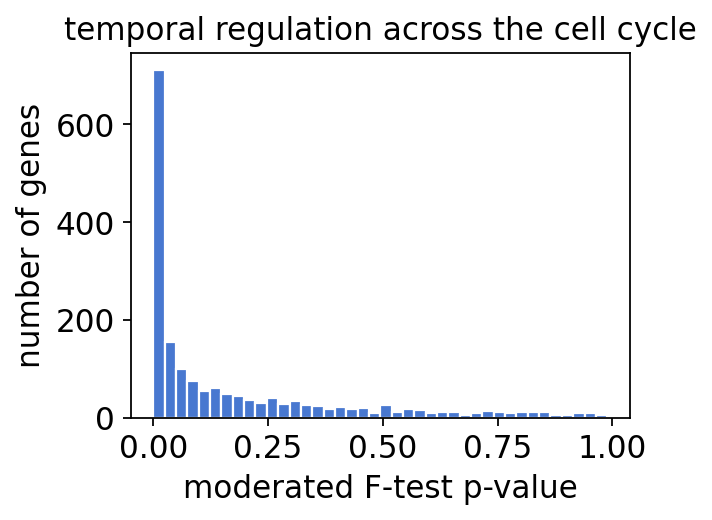

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(res['pvalue'], bins=40, color='#4878d0', edgecolor='white')
ax.set_xlabel('moderated F-test p-value')
ax.set_ylabel('number of genes')
ax.set_title('temporal regulation across the cell cycle')
plt.show()

## 4. What shape — soft-clustering the trajectories

Knowing *which* genes oscillate, question 2 asks *what shape* each oscillation has. Cell-cycle genes do not all peak together — they form **waves**, each set of co-regulated genes peaking at its own phase (G1, S, G2, M).

`ov.bulk.temporal_clusters` groups the regulated genes by trajectory shape using **fuzzy c-means** (the *Mfuzz* method). Fuzzy clustering is the right tool here: a gene is not forced into one cluster but gets a **membership** in each, so genes with a clear wave get a high membership while ambiguous, noisy genes are down-weighted automatically.

Two parameters are estimated, not guessed: the **fuzzifier** `m` (how soft the clustering is — `mestimate` derives it from the data) and the **cluster count** (`n_clusters='auto'` picks the knee of the *Dmin* curve). Here we set `n_clusters=8` explicitly — eight phases is the textbook resolution for the yeast cell cycle.

In [11]:
clusters = ov.bulk.temporal_clusters(expr, time, genes=cellcycle,
                                     n_clusters=8, m='auto', seed=0)
clusters.head()

⏰ Mfuzz fuzzy c-means: 638 genes, 17 time points, c=8, m=1.174

,cluster,membership
YDR391C,5,0.986735
YMR101C,5,0.944032
YDL214C,3,0.988752
YPR127W,5,0.503099
YOL155C,8,0.963816


The `cluster` column is the hard assignment (the cluster of highest membership) and `membership` the gene's confidence in it. Cluster sizes show how the cell-cycle genes split across the expression waves.

In [12]:
clusters['cluster'].value_counts().sort_index()

cluster
1     79
2     40
3    113
4    103
5    100
6     62
7     73
8     68
Name: count, dtype: int64

The **core genes** (`acore`) of a cluster are those with membership above a cut-off (0.5) — the high-confidence representatives of each wave, the genes you would carry forward into enrichment analysis. We standardise the trajectories and re-run the same fuzzy c-means to obtain the `FClust` object that `pymfuzz` needs for its core-gene and plotting helpers.

In [13]:
z = pymfuzz.standardise(yeast_s.copy())
z = pymfuzz.as_expression_matrix(z.to_dataframe().loc[cellcycle])
fc = pymfuzz.mfuzz(z, c=8, m=clusters.attrs['m'], random_state=0)
core = pymfuzz.acore(z, fc, min_acore=0.5)
[len(c.names) for c in core]

[75, 38, 110, 101, 99, 58, 71, 64]

## 5. Visualise the cell-cycle waves

The signature *Mfuzz* output is the **soft-cluster trajectory grid** — one panel per cluster, every gene drawn as a line coloured by its membership (hot colours = core genes). Each panel is a distinct cell-cycle wave: you can read off the phase at which that set of genes peaks.

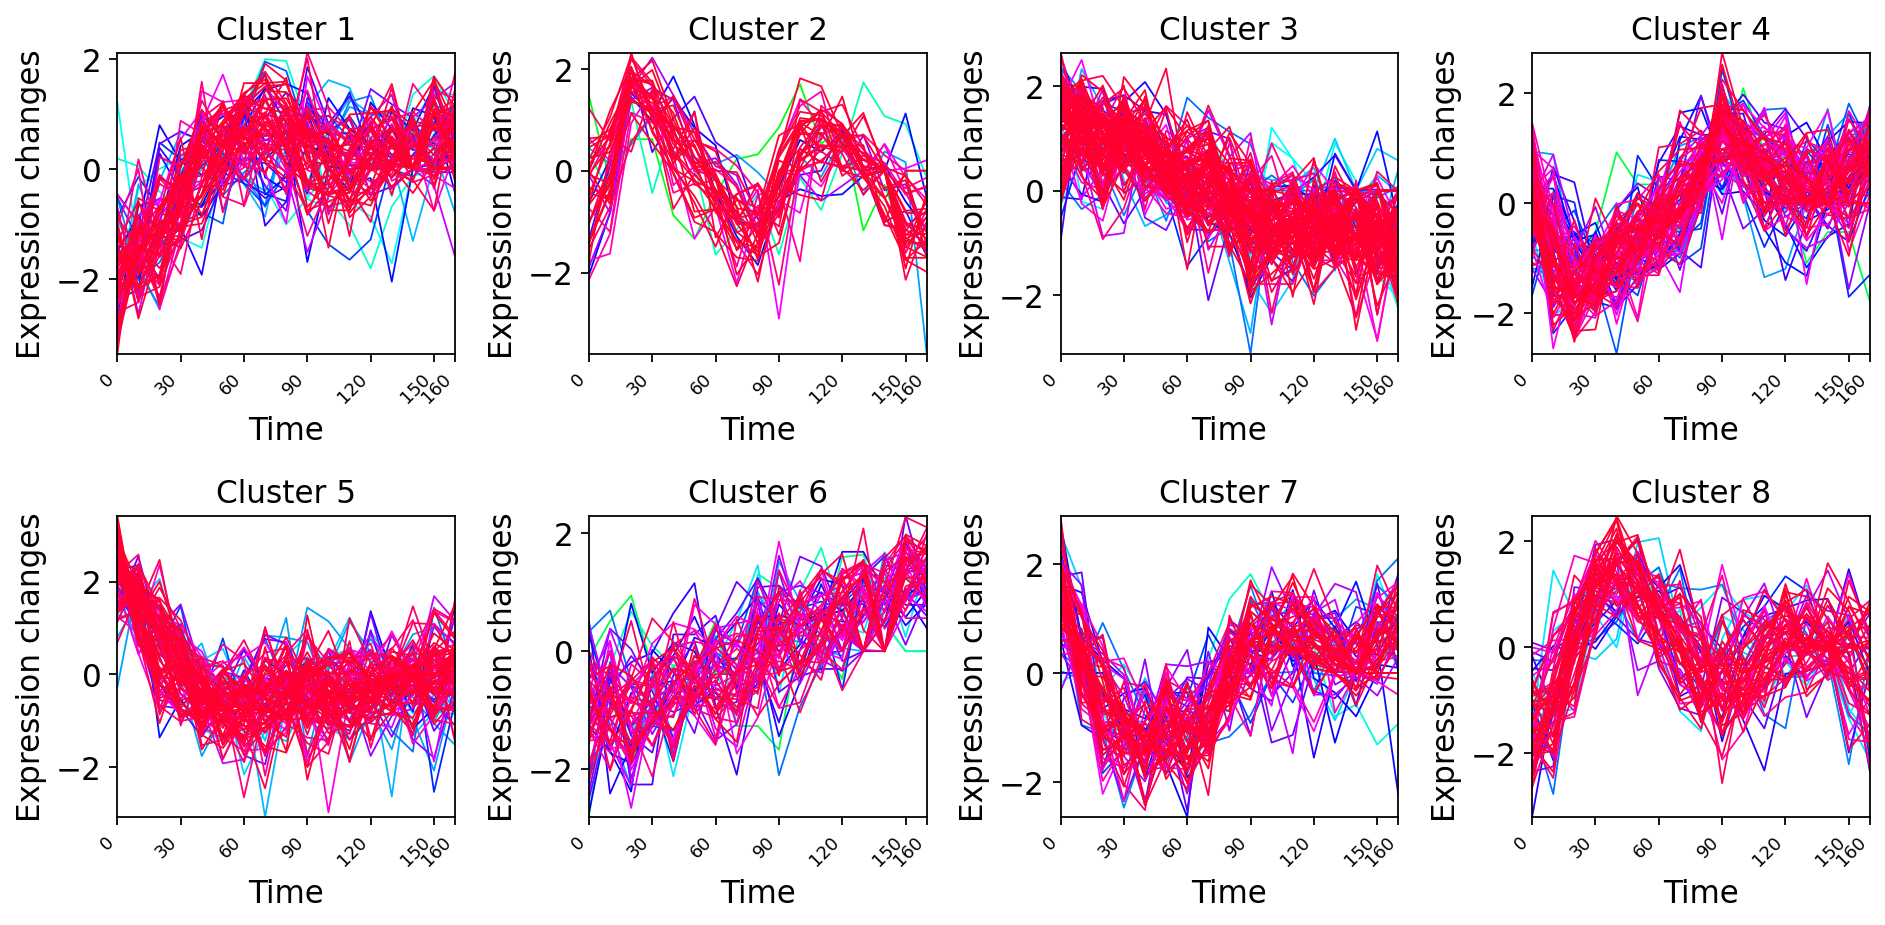

In [14]:
pymfuzz.mfuzz_plot(z, fc, mfrow=(2, 4),
                   time_labels=minutes, figsize=(12, 6))
plt.show()

The **cluster centroids** are the eight wave templates — the average standardised profile of each cluster. Overlaid on one axis they show the cell cycle as a sequence of peaks marching across time: as one wave subsides the next rises, the hallmark of phase-ordered cell-cycle regulation.

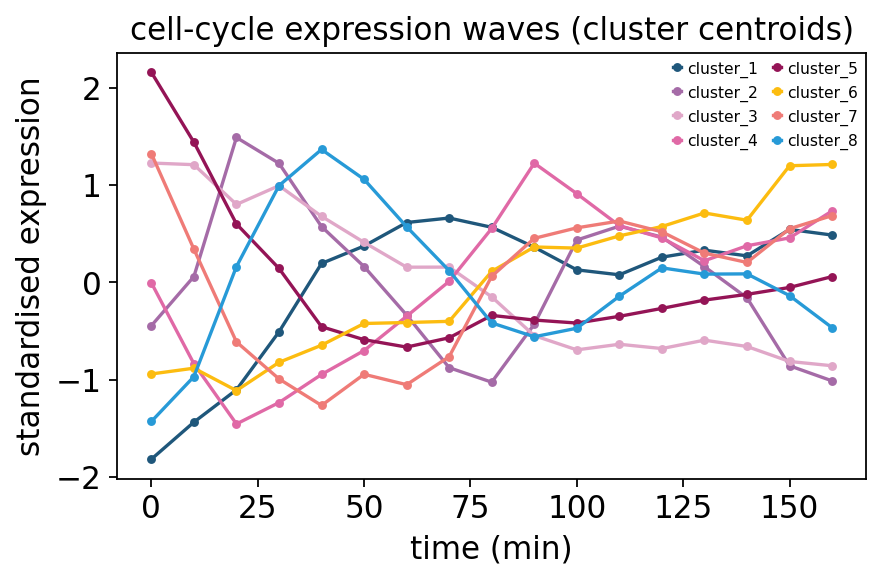

In [15]:
centers = clusters.attrs['centers']
fig, ax = plt.subplots(figsize=(6, 3.5))
for name, row in centers.iterrows():
    ax.plot(minutes, row.values, marker='o', ms=3, label=name)
ax.set_xlabel('time (min)')
ax.set_ylabel('standardised expression')
ax.set_title('cell-cycle expression waves (cluster centroids)')
ax.legend(fontsize=7, ncol=2)
plt.show()

## 6. Closing notes

**Counts vs continuous.** This tutorial used `data_type='continuous'` because the yeast data is microarray log-expression. For an RNA-seq time course you start from a **raw count matrix** — pass `data_type='counts'`, and `timecourse_deg` runs `voom` first to model the count mean-variance trend before fitting. `data_type='auto'` (the default) inspects the matrix and chooses for you: a non-negative near-integer matrix is treated as counts, anything with negative or fractional values as continuous.

**Multiple groups — the `group=` path.** When the experiment has several conditions (e.g. a treated and a control time course), question 3 asks which genes have a *group-specific* trajectory. Passing `group=` switches `timecourse_deg` to the **group x time interaction** F-test — it tests the interaction columns only, so a trend shared by all groups is *not* flagged, only genes whose shape genuinely differs between conditions. For repeated-measures designs (the same subject sampled repeatedly) add `block=` to estimate the within-subject correlation.

Together, `timecourse_deg` (which genes change) and `temporal_clusters` (what shape) give a complete bulk time-course workflow — from raw trajectories to interpretable expression waves.